Reducir estados a binarias


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn import neighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import RobustScaler

# TABLA FINAL

## Calculo de Y

In [2]:
data = pd.read_csv("final_data.csv")
data.reset_index()
data.shape

(97916, 26)

In [3]:
review_mapping_3 = {
    5: 2,
    4: 1,
    3: 1,
    2: 0,
    1: 0
}

review_mapping_2 = {
    5: 2,
    4: 0,
    3: 0,
    2: 0,
    1: 0
}
y_5 = data["media_review_score"]
y_3 = data["media_review_score"].map(review_mapping_3)
y_2 = data["media_review_score"].map(review_mapping_2)
data["media_review_score"] = data["media_review_score"].map(review_mapping_3)
y_dict = {"y_2":y_2,
          "y_3":y_3,
          "y_5":y_5
         }

y_dict

{'y_2': 0        2
 1        0
 2        2
 3        0
 4        2
         ..
 97911    2
 97912    2
 97913    2
 97914    2
 97915    2
 Name: media_review_score, Length: 97916, dtype: int64,
 'y_3': 0        2
 1        1
 2        2
 3        1
 4        2
         ..
 97911    2
 97912    2
 97913    2
 97914    2
 97915    2
 Name: media_review_score, Length: 97916, dtype: int64,
 'y_5': 0        5
 1        4
 2        5
 3        4
 4        5
         ..
 97911    5
 97912    5
 97913    5
 97914    5
 97915    5
 Name: media_review_score, Length: 97916, dtype: int64}

In [4]:
data.columns

Index(['Unnamed: 0', 'order_id', 'media_review_score', 'fecha_ultima_review',
       'order_purchase_timestamp', 'delivered_status', 'delay_time',
       'customer_unique_id', 'customer_state', 'number_payments',
       'payment_value_sum', 'payment_type', 'number_items', 'total_price',
       'total_freight_value', 'total_diff_items', 'product_id', 'seller_id',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_state'],
      dtype='object')

## ANALISIS

In [5]:
# Para un modelo de tipo KNN descartaremos las fechas, ids, y dada la baja relacion entre el estado y
# la satisfaccion se descartara los estados.
data = data.drop(columns = ["fecha_ultima_review", 
                            "order_id",
                            "order_purchase_timestamp",
                            "product_id",
                            "seller_id",
                            "seller_state",
                            "customer_state",
                            "customer_unique_id",
                            "Unnamed: 0"])
data.dtypes

media_review_score                 int64
delivered_status                   int64
delay_time                         int64
number_payments                  float64
payment_value_sum                float64
payment_type                      object
number_items                     float64
total_price                      float64
total_freight_value              float64
total_diff_items                 float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english     object
dtype: object

In [6]:
data.duplicated().sum()

np.int64(1650)

In [7]:
data.isna().sum()

media_review_score               0
delivered_status                 0
delay_time                       0
number_payments                  0
payment_value_sum                0
payment_type                     0
number_items                     0
total_price                      0
total_freight_value              0
total_diff_items                 0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
dtype: int64

In [8]:
data.dtypes

media_review_score                 int64
delivered_status                   int64
delay_time                         int64
number_payments                  float64
payment_value_sum                float64
payment_type                      object
number_items                     float64
total_price                      float64
total_freight_value              float64
total_diff_items                 float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english     object
dtype: object

In [9]:
cols_int = ["number_payments","number_items","total_diff_items", "product_description_lenght", "product_photos_qty"]
data[cols_int] = data[cols_int].astype("int64")
data.dtypes

media_review_score                 int64
delivered_status                   int64
delay_time                         int64
number_payments                    int64
payment_value_sum                float64
payment_type                      object
number_items                       int64
total_price                      float64
total_freight_value              float64
total_diff_items                   int64
product_description_lenght         int64
product_photos_qty                 int64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english     object
dtype: object

In [10]:
# # Hacer histplot mas legibles
# sns.countplot(data, x = "delivered_status", hue = "media_review_score")
# plt.show()
# sns.countplot(data, x = "payment_type", hue = "media_review_score")
# plt.show()
# sns.countplot(data, x = "number_items", hue = "media_review_score")
# plt.show()
# sns.countplot(data, x = "total_diff_items", hue = "media_review_score")
# plt.show()
# sns.countplot(data, x = "product_photos_qty", hue = "media_review_score")
# plt.show()
# sns.countplot(data, x = "product_category_name_english", hue = "media_review_score")
# plt.xticks(rotation=90)  # <- AHORA VERTICAL
# plt.show()

# sns.histplot(data, x = "payment_value_sum", hue = "media_review_score")
# plt.xlim(0, 500)
# plt.show()
# sns.histplot(data, x = "total_price", hue = "media_review_score")
# plt.xlim(0, 500)
# plt.show()
# sns.histplot(data, x = "total_freight_value", hue = "media_review_score")
# plt.xlim(0, 500)
# plt.show()
# sns.histplot(data, x = "product_description_lenght", hue = "media_review_score")
# plt.show()
# sns.histplot(data, x = "product_weight_g", hue = "media_review_score")
# plt.show()
# sns.histplot(data, x = "product_length_cm", hue = "media_review_score")
# plt.show()
# sns.histplot(data, x = "product_height_cm", hue = "media_review_score")
# plt.show()
# sns.histplot(data, x = "product_width_cm", hue = "media_review_score")
# plt.show()
# sns.histplot(data, x = "delay_time", hue = "media_review_score")
# plt.show()

In [11]:
data.columns

Index(['media_review_score', 'delivered_status', 'delay_time',
       'number_payments', 'payment_value_sum', 'payment_type', 'number_items',
       'total_price', 'total_freight_value', 'total_diff_items',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='object')

## MAPEO DE VARIABLES CATEGORICAS Y ESCALADO

In [12]:
for col in data.columns:
    print(f"{col}: diff= {data[col].nunique()},  max= {data[col].max()},  min= {data[col].min()}")

media_review_score: diff= 3,  max= 2,  min= 0
delivered_status: diff= 2,  max= 1,  min= 0
delay_time: diff= 197,  max= 147,  min= -1000
number_payments: diff= 20,  max= 29,  min= 1
payment_value_sum: diff= 27474,  max= 13664.08,  min= 9.59
payment_type: diff= 5,  max= voucher,  min= boleto
number_items: diff= 17,  max= 21,  min= 1
total_price: diff= 7587,  max= 13440.0,  min= 0.85
total_freight_value: diff= 7666,  max= 1794.96,  min= 0.0
total_diff_items: diff= 8,  max= 8,  min= 1
product_description_lenght: diff= 2952,  max= 3992,  min= 4
product_photos_qty: diff= 19,  max= 20,  min= 1
product_weight_g: diff= 2188,  max= 40425.0,  min= 0.0
product_length_cm: diff= 99,  max= 105.0,  min= 7.0
product_height_cm: diff= 102,  max= 105.0,  min= 2.0
product_width_cm: diff= 95,  max= 118.0,  min= 6.0
product_category_name_english: diff= 6,  max= Tools and Construction,  min= Electronics and Technology


In [13]:
# Mapeo de categorias
mapeo_categorias = {
    "Home and Decoration":0,
    "Electronics and Technology":1,
    "Fashion and Personal Care":2,
    "Leisure, Toys and Arts":3,
    "Tools and Construction":4,
    "Miscellaneous and Other Items":5
}

data["product_category_name_english"] = data["product_category_name_english"].map(mapeo_categorias)
data["product_category_name_english"].nunique()
# MinMax de todas las variables 

6

In [14]:
data["payment_type"].isna().sum()

np.int64(0)

In [15]:
data["payment_type"].unique()

array(['credit_card', 'boleto', 'multiple_payments', 'debit_card',
       'voucher'], dtype=object)

In [16]:
# Mapeo de pagos
payment_map = {
    "multiple_payments": 4,
    "credit_card": 3,
    "debit_card": 2,
    "boleto": 1,
    "voucher": 0
}
data["payment_type"] = data["payment_type"].map(payment_map)
data["payment_type"].nunique()

5

In [17]:
data["payment_type"].isna().sum()

np.int64(0)

In [18]:
data.head()

,media_review_score,delivered_status,delay_time,number_payments,payment_value_sum,payment_type,number_items,total_price,total_freight_value,total_diff_items,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,2,1,9,1,72.19,3,1,58.90,13.29,1,598,4,650.0,28.0,9.0,14.0,5
1,1,1,3,1,259.83,3,1,239.90,19.93,1,239,2,30000.0,50.0,30.0,40.0,5
2,2,1,14,1,216.87,3,1,199.00,17.87,1,695,2,3050.0,33.0,13.0,33.0,0
3,1,1,6,1,25.78,3,1,12.99,12.79,1,480,1,200.0,16.0,10.0,15.0,2
4,2,1,16,1,218.04,3,1,199.90,18.14,1,409,1,3750.0,35.0,40.0,30.0,4


In [19]:
# Modificamos las medidas para obtener un volumen en cm3
data["vol"] = data["product_length_cm"] * data["product_height_cm"] * data["product_width_cm"]
data = data.drop(columns = ["product_length_cm","product_height_cm","product_width_cm"]
)

In [20]:
data["delay_time"].min()

np.int64(-1000)

In [21]:
data["delay_time"].max()

np.int64(147)

In [22]:
data.head()

,media_review_score,delivered_status,delay_time,number_payments,payment_value_sum,payment_type,number_items,total_price,total_freight_value,total_diff_items,product_description_lenght,product_photos_qty,product_weight_g,product_category_name_english,vol
0,2,1,9,1,72.19,3,1,58.90,13.29,1,598,4,650.0,5,3528.0
1,1,1,3,1,259.83,3,1,239.90,19.93,1,239,2,30000.0,5,60000.0
2,2,1,14,1,216.87,3,1,199.00,17.87,1,695,2,3050.0,0,14157.0
3,1,1,6,1,25.78,3,1,12.99,12.79,1,480,1,200.0,2,2400.0
4,2,1,16,1,218.04,3,1,199.90,18.14,1,409,1,3750.0,4,42000.0


In [23]:
data.dtypes

media_review_score                 int64
delivered_status                   int64
delay_time                         int64
number_payments                    int64
payment_value_sum                float64
payment_type                       int64
number_items                       int64
total_price                      float64
total_freight_value              float64
total_diff_items                   int64
product_description_lenght         int64
product_photos_qty                 int64
product_weight_g                 float64
product_category_name_english      int64
vol                              float64
dtype: object

In [24]:
data.isna().sum()

media_review_score               0
delivered_status                 0
delay_time                       0
number_payments                  0
payment_value_sum                0
payment_type                     0
number_items                     0
total_price                      0
total_freight_value              0
total_diff_items                 0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_category_name_english    0
vol                              0
dtype: int64

In [25]:
data.columns

Index(['media_review_score', 'delivered_status', 'delay_time',
       'number_payments', 'payment_value_sum', 'payment_type', 'number_items',
       'total_price', 'total_freight_value', 'total_diff_items',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_category_name_english', 'vol'],
      dtype='object')

# CREACION DE MODELO KNN

## Analisis correlacion

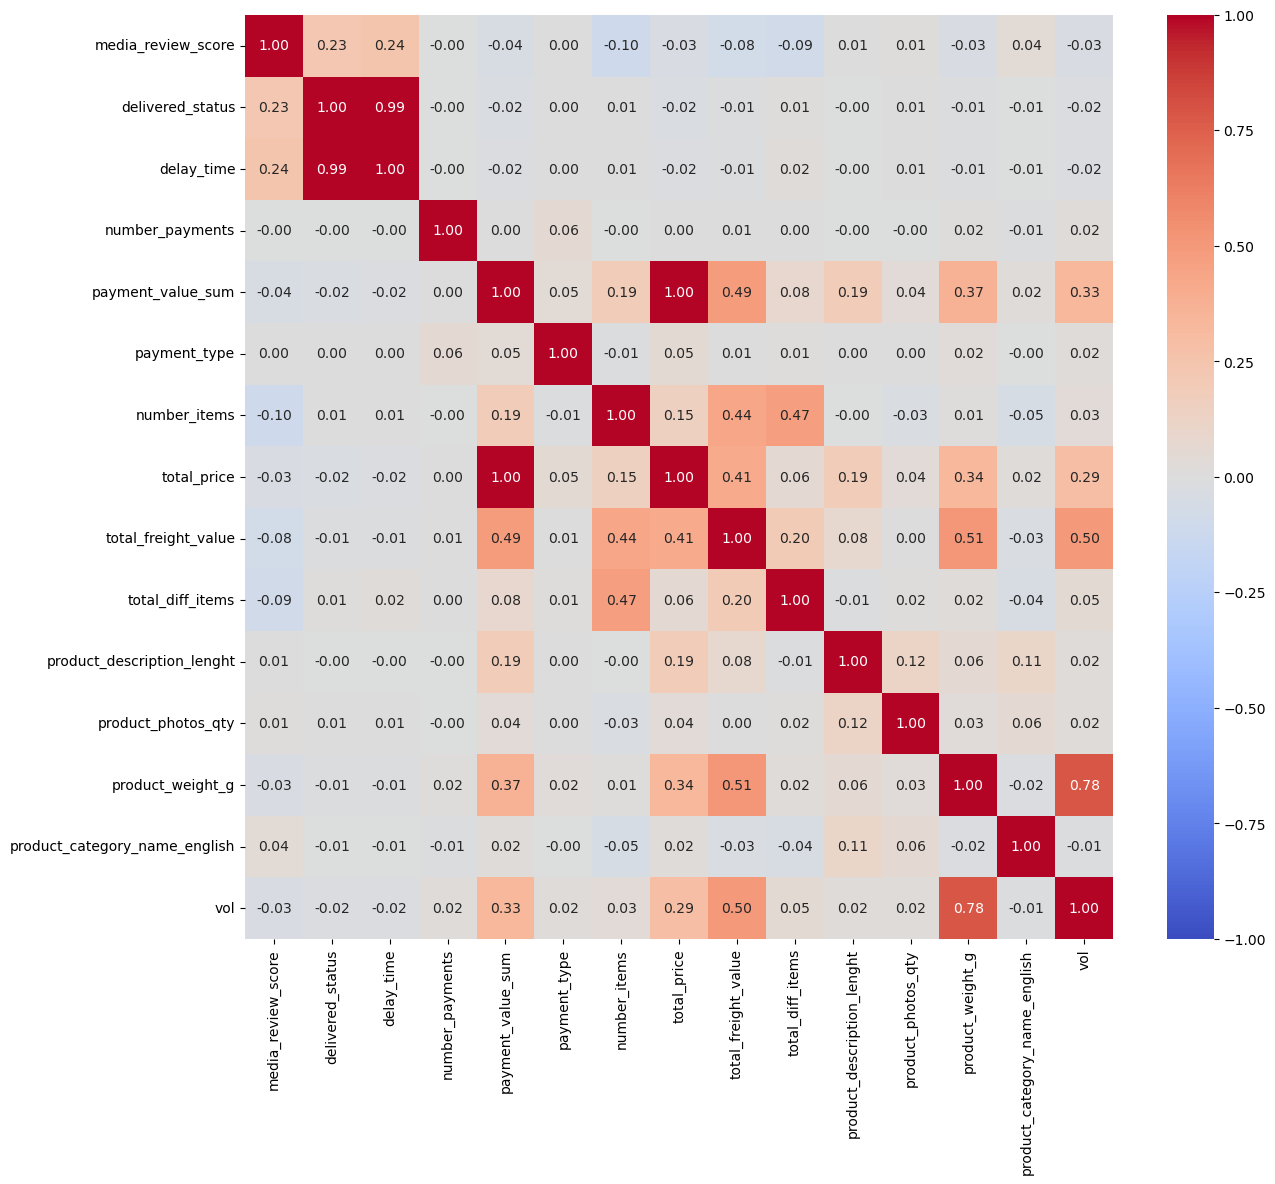

In [26]:
corr = data.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"
)
plt.show()

In [27]:
# Ajustamos para reducir variables intentando perder pocos datos pasando a la densidad del producto
# Eliminamos columnas con alta correlacion entre ellas, domo delivered stats y payment value sum
data["dens"] = data["product_weight_g"] / data["vol"]
data = data.drop(columns = ["payment_value_sum","product_weight_g","vol"])

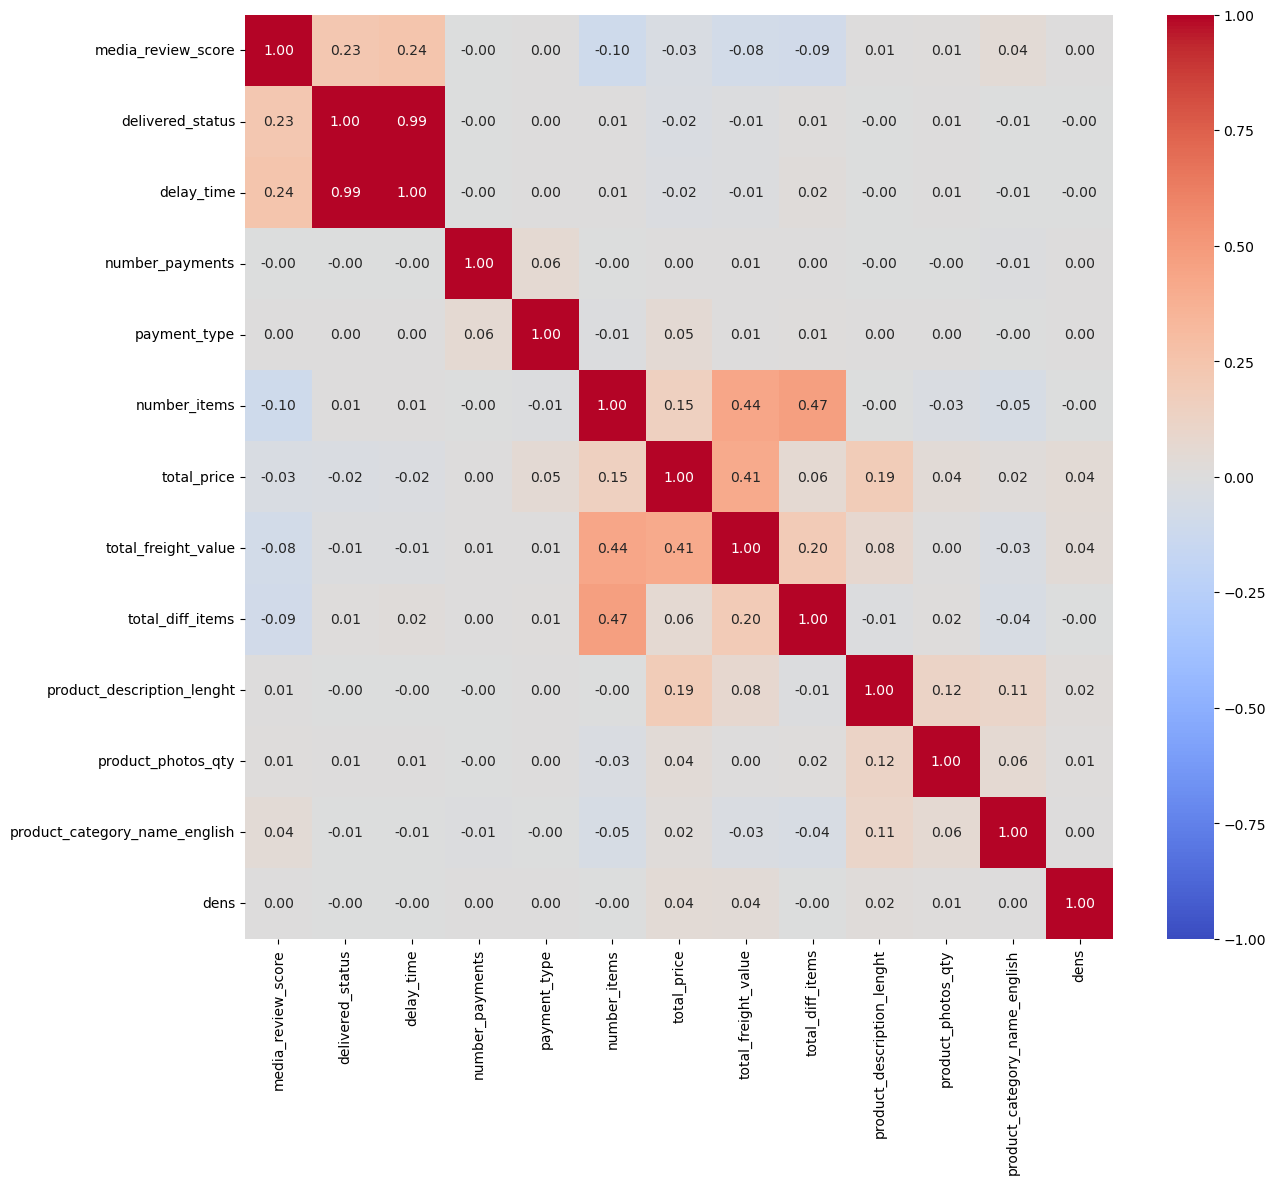

In [28]:
corr = data.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"
)
plt.show()

## OUTLIERS

In [29]:
data.columns

Index(['media_review_score', 'delivered_status', 'delay_time',
       'number_payments', 'payment_type', 'number_items', 'total_price',
       'total_freight_value', 'total_diff_items', 'product_description_lenght',
       'product_photos_qty', 'product_category_name_english', 'dens'],
      dtype='object')

Posibles outliers
- number_items - mas de 6 despreciables
- total_diff_items - 4
- product_photos_qty - 10 o mas
- total_freight_value mayor que 100
- dens tiene valores outliner grandes
- delay time podriamos reducirlo a entre -50 y 50 sin alterar en exceso el numero de datos

Observamos que hay una gran cantidad de outliers que pertenecen a casos reales, seria recomendable clipearlos para reducir las distancias en knn?

In [30]:
data["number_items"] = data["delay_time"].clip(upper=5)
data["total_diff_items"] = data["total_diff_items"].clip(upper=2)
data["product_photos_qty"] = data["product_photos_qty"].clip(upper=7)
data["delay_time"] = data["delay_time"].clip(lower=-50, upper=50)

p99_price = data["total_price"].quantile(0.99)
p99_freight = data["total_freight_value"].quantile(0.99)

data["total_price"] = data["total_price"].clip(upper=p99_price)
data["total_freight_value"] = data["total_freight_value"].clip(upper=p99_freight)

data["log_total_price"] = np.log1p(data["total_price"])
data["log_total_freight_value"] = np.log1p(data["total_freight_value"])
data["log_dens"] = np.log1p(data["dens"])

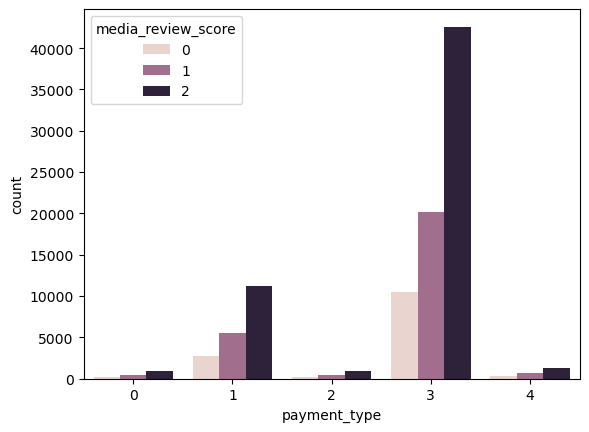

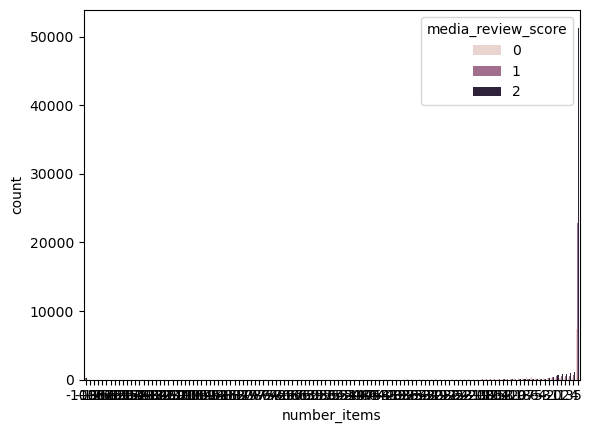

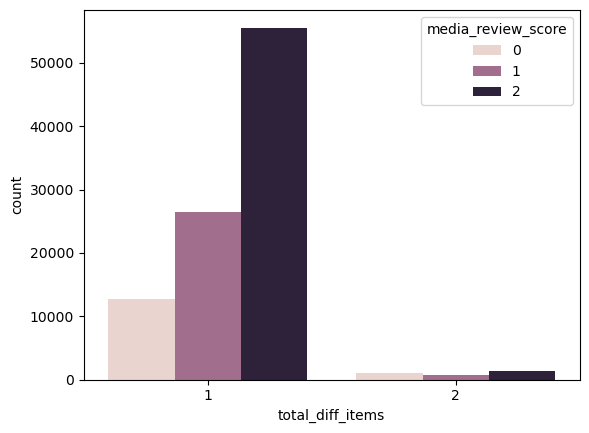

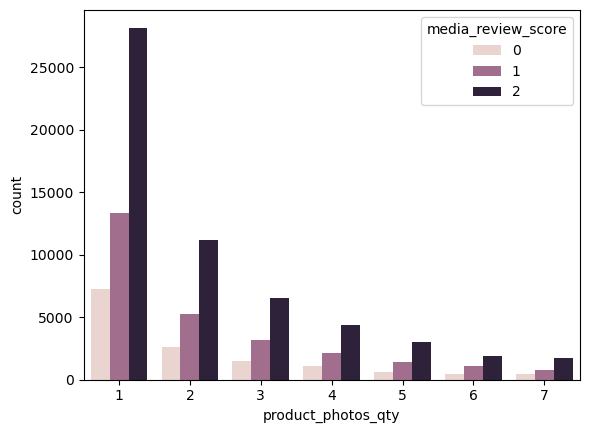

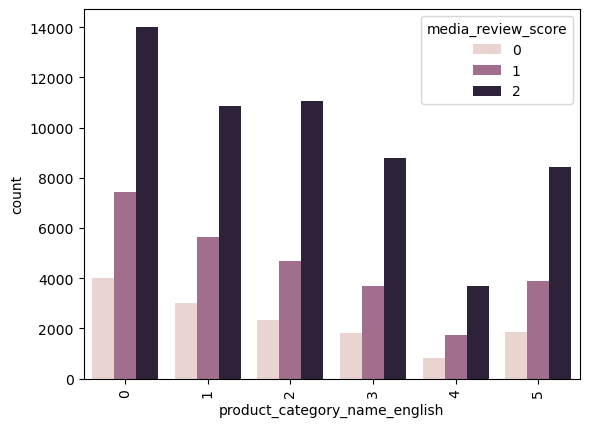

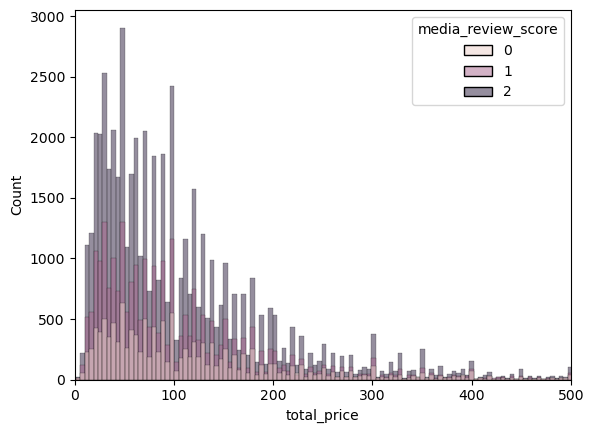

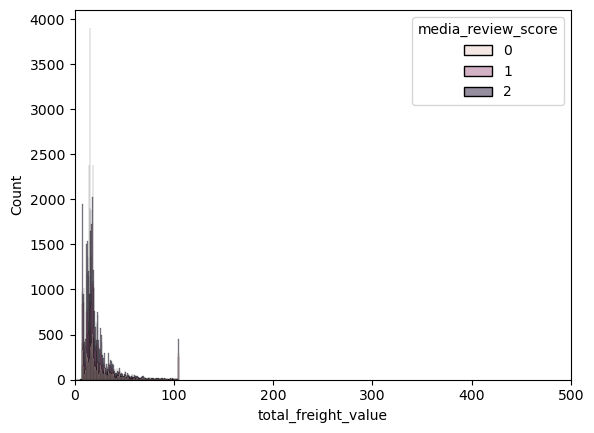

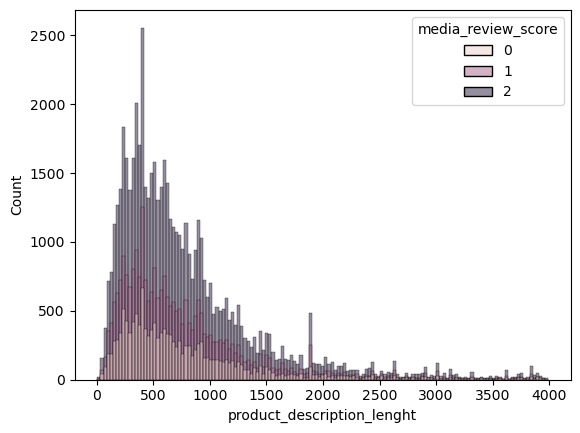

C:\Users\jacin\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


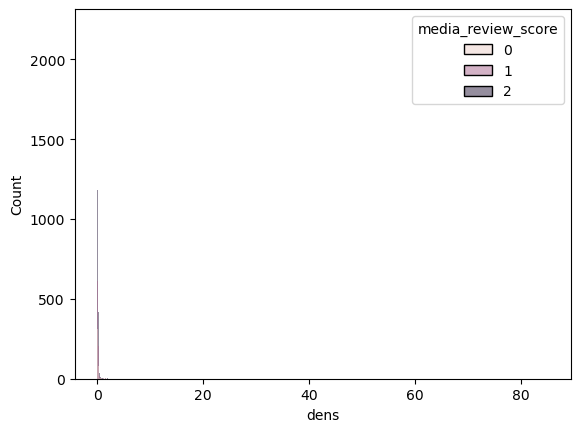

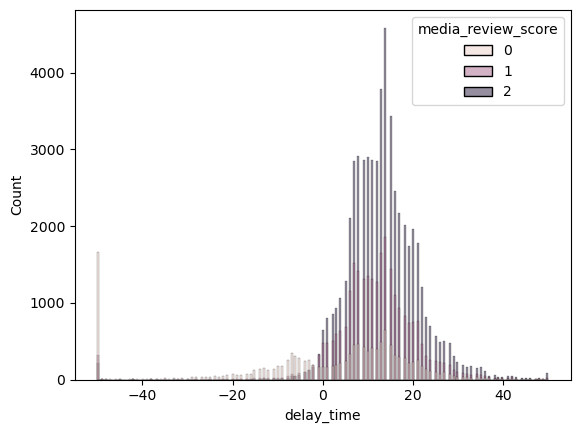

In [31]:
# Hacer histplot mas legibles
sns.countplot(data, x = "payment_type", hue = "media_review_score")
plt.show()
sns.countplot(data, x = "number_items", hue = "media_review_score")
plt.show()
sns.countplot(data, x = "total_diff_items", hue = "media_review_score")
plt.show()
sns.countplot(data, x = "product_photos_qty", hue = "media_review_score")
plt.show()
sns.countplot(data, x = "product_category_name_english", hue = "media_review_score")
plt.xticks(rotation=90)  # <- AHORA VERTICAL
plt.show()

sns.histplot(data, x = "total_price", hue = "media_review_score")
plt.xlim(0, 500)
plt.show()
sns.histplot(data, x = "total_freight_value", hue = "media_review_score")
plt.xlim(0, 500)
plt.show()
sns.histplot(data, x = "product_description_lenght", hue = "media_review_score")
plt.show()
sns.histplot(data, x = "dens", hue = "media_review_score")
plt.show()
sns.histplot(data, x = "delay_time", hue = "media_review_score")
plt.show()

## Modelo

In [32]:
# ESCALAMOS
scaler = RobustScaler()
for col in data.columns:
    data[col] = scaler.fit_transform(data[[col]])
    print(f"{col} - val_diff: {data[col].nunique()} - val max: {data[col].max()} - val min: {data[col].min()}")

media_review_score - val_diff: 3 - val max: 0.0 - val min: -2.0
delivered_status - val_diff: 2 - val max: 0.0 - val min: -1.0
delay_time - val_diff: 101 - val max: 3.8 - val min: -6.2
number_payments - val_diff: 20 - val max: 28.0 - val min: 0.0
payment_type - val_diff: 5 - val max: 1.0 - val min: -3.0
number_items - val_diff: 120 - val max: 0.0 - val min: -1005.0
total_price - val_diff: 7127 - val max: 8.760576923076924 - val min: -0.8274038461538462
total_freight_value - val_diff: 6792 - val max: 8.617059980334332 - val min: -1.687315634218289
total_diff_items - val_diff: 2 - val max: 1.0 - val min: 0.0
product_description_lenght - val_diff: 2952 - val max: 5.320251177394034 - val min: -0.9403453689167975
product_photos_qty - val_diff: 7 - val max: 2.5 - val min: -0.5
product_category_name_english - val_diff: 6 - val max: 1.0 - val min: -0.6666666666666666
dens - val_diff: 13823 - val max: 674.8854954652296 - val min: -0.8942649461082363
log_total_price - val_diff: 7086 - val max: 2.

In [33]:
# definimos funcion para generar modelos
def model_generator(X_train, X_test, y_train, y_test, n_neighbors):
    modelo = neighbors.KNeighborsClassifier(
        n_neighbors = n_neighbors,
        weights="distance"
        )
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    cv_f1 = cross_val_score(modelo, X_train, y_train, cv=5, scoring="f1_macro").mean()

    return (accuracy,f1,cv_f1)

In [34]:
def generate_data_train_test(X,y):
    return train_test_split(
        X, y,
        train_size = 0.75,
        test_size = 0.25
    )

In [35]:
X = data.drop(columns = "media_review_score")
X_train, X_test, y_train, y_test = generate_data_train_test(X,y_3)

In [36]:
results = {}
for k in range(1,30):
    results[k] = model_generator(X_train, X_test, y_train, y_test, k)

data_results = pd.DataFrame.from_dict(
    results,
    orient="index",
    columns=["accuracy", "f1", "cv_f1"]
)
data_results.index.name = "neightbors"
data_results.head()

,accuracy,f1,cv_f1
neightbors,,,
1,0.496507,0.433791,0.430387
2,0.494465,0.433385,0.430236
3,0.528739,0.454414,0.451196
4,0.541566,0.466012,0.461545
5,0.550962,0.465557,0.465192


In [37]:
data_results.loc[data_results["f1"].idxmax()]

accuracy    0.570203
f1          0.473023
cv_f1       0.473549
Name: 8, dtype: float64

# RESULTADOS

"uniform"
accuracy    0.531599
f1          0.434684
cv_f1       0.434154
Name: 5, dtype: float64

"distance"
accuracy    0.530659
f1          0.426348
cv_f1       0.427739
Name: 5, dtype: float
"distance" + StandardScaler
accuracy    0.551125
f1          0.434482
cv_f1       0.425284
Name: 8, dtype: floa

"uniform" + StandardScaler
accuracy    0.530904
f1          0.436421
cv_f1       0.432901
Name: 5, dtype: float
"distance" + "minkowski", p=2

--------------------------------------------------------------------------------------
Seguimos variando datos sin mejorar lo ya encontrado, nos quedamos con el mejor modelo que seria 
"distance" + StandardScaler con 8 vecinos.
accuracy    0.551125 - muy bajo
f1          0.434482 - consistente pero generaliza mal
cv_f1       0.425284

El modelo es débil, pero estable. No está roto, está limitado.

Tras varios intentos y limpiando la matriz de altas correlaciones, nos encontramos con valores muy similares e insuficientes, por lo tanto no es un modelo de calidad.

accuracy    0.555946
f1          0.437575
cv_f1       0.4359



Procedemos a intentar mejorarlo, reduciendo outliers en delay_timet64
64t6464



# MEJORA MODELO

Retiraremos las columnas que tengan valores outliners, nos quedaremso solo con los que esten entregados
- Mejora de outliers
- Extraccion de keywords de reviews